In [1]:
import kagglehub
import pandas as pd
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = kagglehub.dataset_download(
    "alexteboul/diabetes-health-indicators-dataset"
)
csv_path = os.path.join(path, "diabetes_binary_health_indicators_BRFSS2015.csv")
df = pd.read_csv(csv_path)

RANDOM_STATE = 67

## Análise Exploratória

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [4]:
df['Diabetes_binary'].value_counts(normalize=True)

Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64

In [5]:
duplicates = df[df.duplicated()]
print("Duplicate Rows : ",len(duplicates))
duplicates.head()

Duplicate Rows :  24206


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
1242,1.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0
1563,0.0,0.0,0.0,1.0,21.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
2700,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
3160,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
3332,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0


In [6]:
df.drop_duplicates(inplace = True)

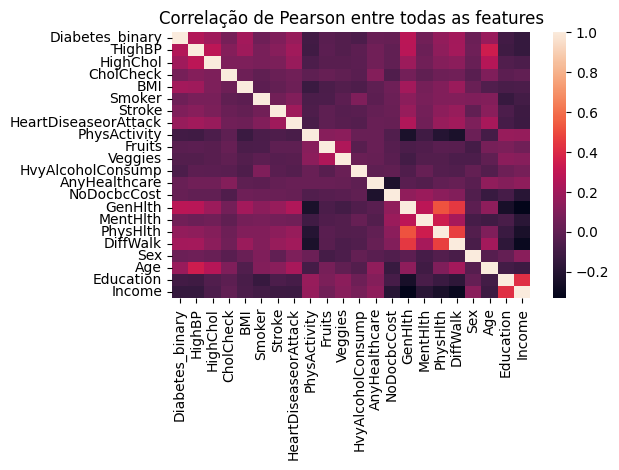

In [7]:
corr_completa = df.corr(method='pearson')
sns.heatmap(
    corr_completa
)
plt.title('Correlação de Pearson entre todas as features')
plt.savefig("images\\full_pearson.png")
plt.tight_layout()
plt.show()


In [8]:
df.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

## Pré Processamento

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [10]:
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Selecao Features

In [12]:
from sklearn.feature_selection import mutual_info_classif

In [15]:
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=RANDOM_STATE)

# Criar um DataFrame para facilitar a visualização e ordenação (Ranking)
mi_features = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

# Apresentar a quantidade inicial de atributos e o ranking gerado
print(f"Quantidade inicial de atributos: {X.shape[1]}")
print("\nRanking de Importância das Features:")
mi_features

Quantidade inicial de atributos: 21

Ranking de Importância das Features (Etapa 3):


,Feature,MI_Score
0,HighBP,0.048025
1,GenHlth,0.044858
2,HighChol,0.031494
3,DiffWalk,0.026989
4,BMI,0.024901
5,Age,0.024591
6,PhysActivity,0.020859
7,PhysHlth,0.020621
8,HeartDiseaseorAttack,0.020463
9,Smoker,0.017351


C:\Users\Miguel\AppData\Local\Temp\ipykernel_20836\3057217112.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_features, palette='viridis')


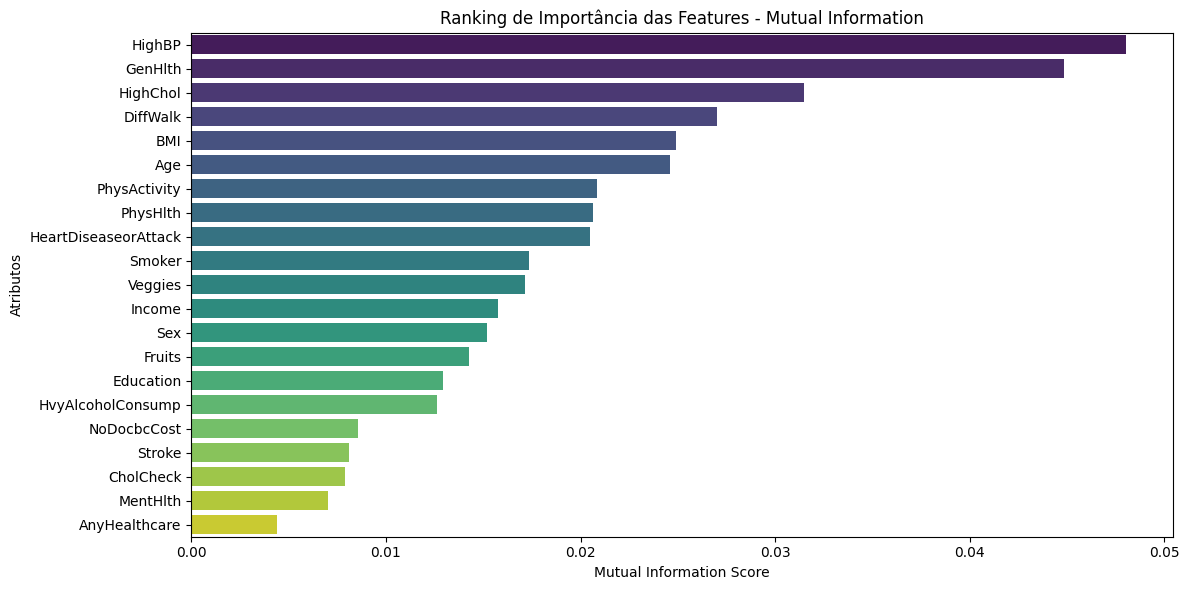

Quantidade final de atributos selecionados: 10
Features escolhidas: ['HighBP', 'GenHlth', 'HighChol', 'DiffWalk', 'BMI', 'Age', 'PhysActivity', 'PhysHlth', 'HeartDiseaseorAttack', 'Smoker']


In [16]:
plt.figure(figsize=(12, 6))
sns.barplot(x='MI_Score', y='Feature', data=mi_features, palette='viridis')
plt.title('Ranking de Importância das Features - Mutual Information')
plt.xlabel('Mutual Information Score')
plt.ylabel('Atributos')
plt.tight_layout()
plt.show()

# Critério de corte: Selecionar as Top 10 features com maior score de MI
K_FEATURES = 10
selected_features = mi_features['Feature'].head(K_FEATURES).tolist()

print(f"Quantidade final de atributos selecionados: {K_FEATURES}")
print(f"Features escolhidas: {selected_features}")

# Criar conjuntos de dados filtrados apenas com as features selecionadas
X_train_selected = pd.DataFrame(X_train_scaled, columns=X.columns)[selected_features]
X_test_selected = pd.DataFrame(X_test_scaled, columns=X.columns)[selected_features]

## Classificação Binária
### Markdown

In [18]:
from sklearn.neural_network import MLPClassifier
#from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ClassificationReportDisplay

In [24]:
mlp_all = MLPClassifier(
    hidden_layer_sizes=(64, 32), # 2 camadas ocultas (justificar no relatório)
    activation='relu',
    solver='adam',
    batch_size=128,
    max_iter=150,                  # Controla as épocas
    random_state=RANDOM_STATE,
    early_stopping=False          # Desativado por enquanto (exigido na Etapa 7)
)
mlp_all.fit(X_train_scaled, y_train)

MLPClassifier(batch_size=128, hidden_layer_sizes=(64, 32), max_iter=150,
              random_state=67)

In [26]:
mlp_sel = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    batch_size=128,
    max_iter=150,
    random_state=RANDOM_STATE,
    early_stopping=False
)
mlp_sel.fit(X_train_selected, y_train)

MLPClassifier(batch_size=128, hidden_layer_sizes=(64, 32), max_iter=150,
              random_state=67)

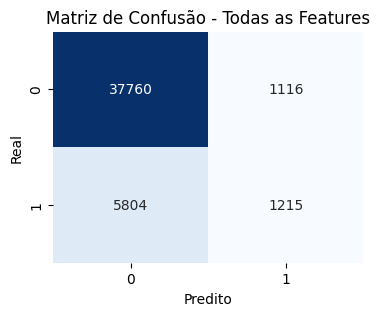

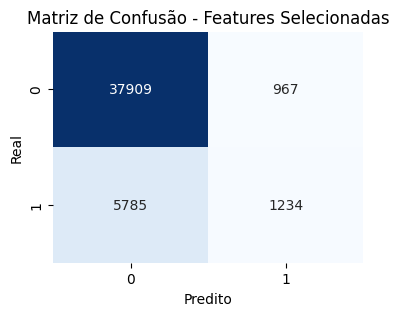


Comparativo de Desempenho (Etapa 3 e 4):


,Cenário,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Todas as Features,0.849221,0.521236,0.173102,0.259893,0.806094
1,Features Selecionadas,0.852882,0.560654,0.175809,0.267679,0.810827


In [23]:
def avaliar_classificacao_binaria(modelo, X_test_data, y_true, nome_cenario):
    preds = modelo.predict(X_test_data)
    probs = modelo.predict_proba(X_test_data)[:, 1]
    
    metrics = {
        "Cenário": nome_cenario,
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds),
        "F1-Score": f1_score(y_true, preds),
        "ROC-AUC": roc_auc_score(y_true, probs)
    }
    
    # Exibir a Matriz de Confusão exigida
    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusão - {nome_cenario}')
    plt.ylabel('Real')
    plt.xlabel('Predito')
    plt.show()
    
    return metrics

# Avaliar ambos os modelos
res_all = avaliar_classificacao_binaria(mlp_all, X_test_scaled, y_test, "Todas as Features")
res_sel = avaliar_classificacao_binaria(mlp_sel, X_test_selected, y_test, "Features Selecionadas")

# Tabela comparativa final para discussão no relatório
df_comparativo = pd.DataFrame([res_all, res_sel])
print("\nComparativo de Desempenho (Etapa 3 e 4):")
df_comparativo